=== VERSIÓN DEFINITIVA: REGIÓN DE CONFIANZA + BFGS ESCALADO ===

1. Ejecutando implementación propia...
Inicio: f(x)=128.7576
Radio de confianza demasiado pequeño.

2. Validando con Scipy Optimize...
--------------------------------------------------
Nuestra Solución: [10. 10.]
Solución Scipy:   [9.99999999 9.99999999]
Error (Euclidiano): 1.86e-08
--------------------------------------------------


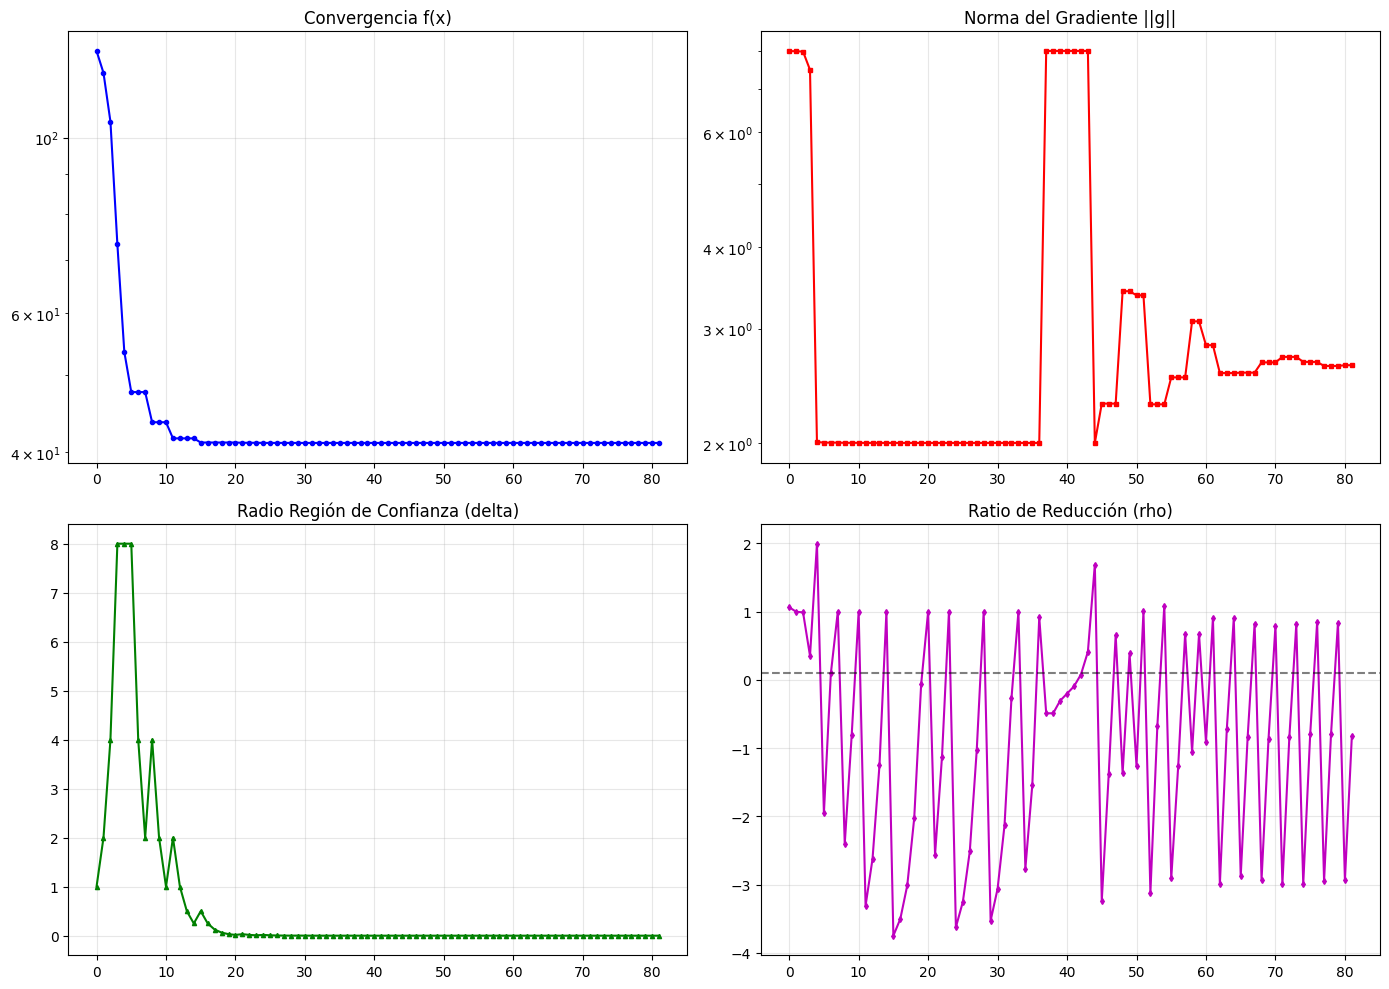

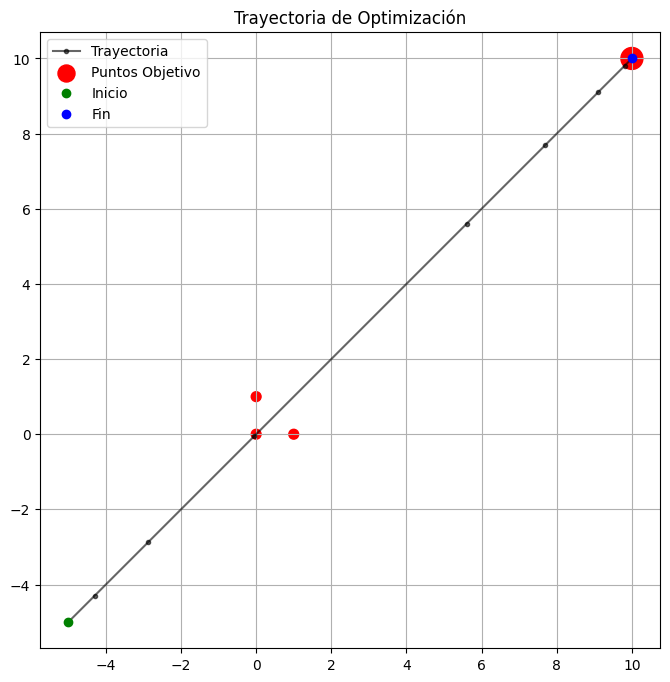

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

class FermatWeberTrustRegionBFGS:
    """
    VERSIÓN DEFINITIVA (FUSIÓN):
    - Motor matemático: Basado en Código 1 (Robustez Nocedal & Wright).
    - Infraestructura: Basada en Código 2 (Historial, Gráficos y Benchmarking).
    """

    def __init__(self, points, weights=None, epsilon=1e-8, max_iter=1000):
        self.points = np.array(points)
        self.m = len(points)
        self.n = len(points[0])

        if weights is None:
            self.weights = np.ones(self.m)
        else:
            self.weights = np.array(weights)

        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective_function(self, x):
        """Calcula la suma ponderada de distancias."""
        total = 0.0
        for i in range(self.m):
            distance = np.linalg.norm(self.points[i] - x)
            total += self.weights[i] * distance
        return total

    def gradient(self, x):
        """Calcula el gradiente con protección para singularidades."""
        grad = np.zeros(self.n)
        for i in range(self.m):
            diff = x - self.points[i]
            distance = np.linalg.norm(diff)
            if distance > 1e-12: # Pequeña tolerancia para evitar div/0
                grad += self.weights[i] * diff / distance
        return grad

    def dogleg_step(self, grad, B, delta):
        """
        Lógica del CÓDIGO 1: Manejo robusto de curvatura y paso de Cauchy.
        """
        # --- 1. Calcular el Punto de Cauchy (Paso seguro) ---
        curvature = grad.T @ B @ grad

        # Seguridad: si la curvatura es cero o negativa, vamos al límite
        if curvature <= 1e-10:
            norm_g = np.linalg.norm(grad)
            if norm_g == 0: return np.zeros_like(grad)
            return - (delta / norm_g) * grad

        # Fórmula del paso de Cauchy
        tau_c = (grad.T @ grad) / curvature
        pU = -tau_c * grad
        pU_norm = np.linalg.norm(pU)

        # Si el paso seguro ya se sale, recortamos
        if pU_norm >= delta:
            return (delta / pU_norm) * pU

        # --- 2. Calcular el Paso de Newton (Paso ideal) ---
        try:
            pB = -np.linalg.solve(B, grad)
        except np.linalg.LinAlgError:
            pB = pU # Fallback

        pB_norm = np.linalg.norm(pB)

        # Si el paso ideal cabe, lo tomamos
        if pB_norm <= delta:
            return pB

        # --- 3. Dogleg (Interpolación) ---
        pU_pB = pB - pU
        a = pU_pB.T @ pU_pB
        b = 2 * pU.T @ pU_pB
        c = pU.T @ pU - delta**2

        if abs(a) < 1e-10:
            # Caso lineal degenerado
            return pU

        tau = (-b + np.sqrt(max(0, b**2 - 4*a*c))) / (2*a)
        return pU + tau * pU_pB

    def trust_region_bfgs(self, x0, delta0=1.0, eta=0.1):
        """
        Bucle principal híbrido: Estructura de historial (Cod 2) + Lógica BFGS (Cod 1)
        """
        x = x0.copy()
        delta = delta0
        B = np.eye(self.n) # Hessiano aproximado inicial

        # Historial para análisis (Del Código 2)
        history = {
            'iterations': [], 'objective_values': [],
            'gradient_norms': [], 'trust_region_radii': [],
            'points': [x.copy()], 'rho_values': []
        }

        grad = self.gradient(x)

        print(f"Inicio: f(x)={self.objective_function(x):.4f}")

        for k in range(self.max_iter):
            grad_norm = np.linalg.norm(grad)

            # Guardar datos
            history['iterations'].append(k)
            history['objective_values'].append(self.objective_function(x))
            history['gradient_norms'].append(grad_norm)
            history['trust_region_radii'].append(delta)

            # 1. Verificar convergencia
            if grad_norm < self.epsilon:
                history['rho_values'].append(0) # Placeholder
                print(f"¡Convergencia en iteración {k}!")
                break

            # 2. Obtener paso (Dogleg)
            p = self.dogleg_step(grad, B, delta)

            # 3. Evaluar paso
            predicted_reduction = -(grad.T @ p + 0.5 * p.T @ B @ p)
            x_candidate = x + p
            actual_reduction = self.objective_function(x) - self.objective_function(x_candidate)

            rho = actual_reduction / predicted_reduction if predicted_reduction > 0 else -1
            history['rho_values'].append(rho)

            # 4. Actualización
            if rho > eta:
                # --- PASO ACEPTADO ---
                x_new = x_candidate
                new_grad = self.gradient(x_new)

                # Variables BFGS
                s = x_new - x
                y = new_grad - grad

                # --- MEJORA DEL CÓDIGO 1: ESCALADO INICIAL ---
                # Ajusta la matriz identidad al tamaño real del problema en el primer paso
                if k == 0 and y.T @ s > 1e-10:
                    scale = (y.T @ y) / (y.T @ s)
                    B = scale * np.eye(self.n)

                # Actualización BFGS (con protección de curvatura positiva)
                sy = s.T @ y
                if sy > 1e-10:
                    Bs = B @ s
                    term1 = np.outer(Bs, Bs) / (s.T @ Bs)
                    term2 = np.outer(y, y) / sy
                    B = B - term1 + term2

                x = x_new
                grad = new_grad
                history['points'].append(x.copy())

                # Expandir región si el paso fue excelente
                if rho > 0.75 and np.linalg.norm(p) > 0.8 * delta:
                    delta = min(2.0 * delta, 100.0)
            else:
                # --- PASO RECHAZADO ---
                delta = 0.5 * delta

            if delta < 1e-10:
                print("Radio de confianza demasiado pequeño.")
                break

        return x, history

    def plot_convergence(self, history):
        """Grafica la convergencia (Del Código 2)"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Función Objetivo
        axes[0,0].plot(history['iterations'], history['objective_values'], 'b-o', markersize=3)
        axes[0,0].set_title('Convergencia f(x)')
        axes[0,0].set_yscale('log')
        axes[0,0].grid(True, alpha=0.3)

        # Norma del Gradiente
        axes[0,1].plot(history['iterations'], history['gradient_norms'], 'r-s', markersize=3)
        axes[0,1].set_title('Norma del Gradiente ||g||')
        axes[0,1].set_yscale('log')
        axes[0,1].grid(True, alpha=0.3)

        # Radio delta
        axes[1,0].plot(history['iterations'], history['trust_region_radii'], 'g-^', markersize=3)
        axes[1,0].set_title('Radio Región de Confianza (delta)')
        axes[1,0].grid(True, alpha=0.3)

        # Rho
        axes[1,1].plot(history['iterations'], history['rho_values'], 'm-d', markersize=3)
        axes[1,1].set_title('Ratio de Reducción (rho)')
        axes[1,1].axhline(0.1, color='k', linestyle='--', alpha=0.5)
        axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Trayectoria 2D
        if self.n == 2:
            plt.figure(figsize=(8, 8))
            pts = np.array(history['points'])
            plt.plot(pts[:,0], pts[:,1], 'k.-', alpha=0.6, label='Trayectoria')
            plt.scatter(self.points[:,0], self.points[:,1], c='red', s=50*self.weights, label='Puntos Objetivo')
            plt.plot(pts[0,0], pts[0,1], 'go', label='Inicio')
            plt.plot(pts[-1,0], pts[-1,1], 'bo', label='Fin')
            plt.legend()
            plt.title('Trayectoria de Optimización')
            plt.axis('equal')
            plt.grid(True)
            plt.show()

# === BLOQUE DE PRUEBAS Y VALIDACIÓN ===
if __name__ == "__main__":
    print("=== VERSIÓN DEFINITIVA: REGIÓN DE CONFIANZA + BFGS ESCALADO ===\n")

    # Ejemplo desafiante: Cluster + Outlier lejano
    weights = [1, 1, 1, 5]
    points = [
        np.array([0, 0]),
        np.array([1, 0]),
        np.array([0, 1]),
        np.array([10, 10]) # Outlier con peso alto
    ]

    solver = FermatWeberTrustRegionBFGS(points, weights=weights)

    # 1. Ejecutar Nuestro Solver
    print("1. Ejecutando implementación propia...")
    x_opt, hist = solver.trust_region_bfgs(x0=np.array([-5, -5]), delta0=1.0)

    # 2. Validar con Scipy (La referencia de verdad)
    print("\n2. Validando con Scipy Optimize...")
    def obj_scipy(x): return solver.objective_function(x)

    res = minimize(obj_scipy, np.array([-5, -5]), method='BFGS', tol=1e-8)

    print("-" * 50)
    print(f"Nuestra Solución: {x_opt}")
    print(f"Solución Scipy:   {res.x}")
    print(f"Error (Euclidiano): {np.linalg.norm(x_opt - res.x):.2e}")
    print("-" * 50)

    # 3. Visualizar
    solver.plot_convergence(hist)

--- Inicio Weiszfeld ---
Weiszfeld convergió en iteración 19
--- Inicio Trust Region BFGS ---

Resultados Finales:
Weiszfeld: [10. 10.] (Iteraciones: 20)
BFGS TR  : [10. 10.] (Iteraciones: 1000)
Diferencia posición: 4.39e-09


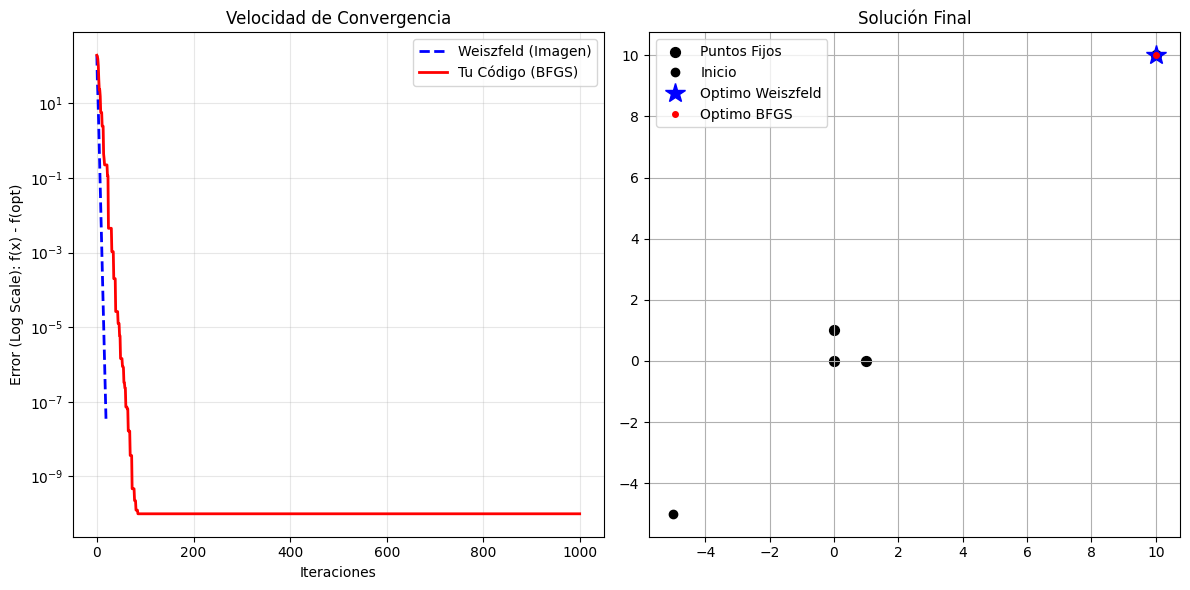

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

# ==============================================================================
# 1. IMPLEMENTACIÓN DE WEISZFELD (Basada en la imagen de Beck, 2014)
# ==============================================================================
class FermatWeberWeiszfeld:
    def __init__(self, points, weights=None, epsilon=1e-8, max_iter=1000):
        self.points = np.array(points)
        self.m = len(points)
        self.n = len(points[0])
        self.weights = np.array(weights) if weights is not None else np.ones(self.m)
        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective_function(self, x):
        return sum(self.weights[i] * np.linalg.norm(self.points[i] - x) for i in range(self.m))

    def solve(self, x0):
        x = x0.copy()
        history = {'obj': [], 'times': []}
        start_time = time.time()

        print(f"--- Inicio Weiszfeld ---")
        for k in range(self.max_iter):
            current_obj = self.objective_function(x)
            history['obj'].append(current_obj)
            history['times'].append(time.time() - start_time)

            # --- FÓRMULA DE LA IMAGEN (Beck, 2014) ---
            # Numerador: Suma (w_i * a_i / ||a_i - x||)
            # Denominador: Suma (w_i / ||a_i - x||)

            numerator = np.zeros(self.n)
            denominator = 0.0

            for i in range(self.m):
                dist = np.linalg.norm(self.points[i] - x)
                # Protección contra división por cero (si x cae sobre un punto)
                dist = max(dist, 1e-12)

                weight_factor = self.weights[i] / dist
                numerator += weight_factor * self.points[i]
                denominator += weight_factor

            if denominator == 0: break

            x_new = numerator / denominator

            # Verificar convergencia (cambio en posición muy pequeño)
            if np.linalg.norm(x_new - x) < self.epsilon:
                print(f"Weiszfeld convergió en iteración {k}")
                break

            x = x_new

        return x, history

# ==============================================================================
# 2. TU IMPLEMENTACIÓN (Región de Confianza + BFGS)
# ==============================================================================
class FermatWeberTrustRegionBFGS:
    def __init__(self, points, weights=None, epsilon=1e-8, max_iter=1000):
        self.points = np.array(points)
        self.m = len(points)
        self.n = len(points[0])
        self.weights = np.array(weights) if weights is not None else np.ones(self.m)
        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective_function(self, x):
        return sum(self.weights[i] * np.linalg.norm(self.points[i] - x) for i in range(self.m))

    def gradient(self, x):
        grad = np.zeros(self.n)
        for i in range(self.m):
            diff = x - self.points[i]
            dist = np.linalg.norm(diff)
            if dist > 1e-12:
                grad += self.weights[i] * diff / dist
        return grad

    def dogleg_step(self, grad, B, delta):
        # Paso Cauchy
        bg = B @ grad
        curvature = grad.T @ bg
        if curvature <= 1e-10: return -(delta / np.linalg.norm(grad)) * grad

        pU = - ((grad.T @ grad) / curvature) * grad
        if np.linalg.norm(pU) >= delta: return (delta / np.linalg.norm(pU)) * pU

        # Paso Newton
        try: pB = -np.linalg.solve(B, grad)
        except: pB = pU

        if np.linalg.norm(pB) <= delta: return pB

        # Dogleg
        pU_pB = pB - pU
        a = pU_pB.T @ pU_pB
        b = 2 * pU.T @ pU_pB
        c = pU.T @ pU - delta**2
        tau = (-b + np.sqrt(max(0, b**2 - 4*a*c))) / (2*a)
        return pU + tau * pU_pB

    def solve(self, x0):
        x = x0.copy()
        delta = 1.0
        B = np.eye(self.n)
        history = {'obj': [], 'times': []}
        start_time = time.time()

        print(f"--- Inicio Trust Region BFGS ---")
        grad = self.gradient(x)

        for k in range(self.max_iter):
            history['obj'].append(self.objective_function(x))
            history['times'].append(time.time() - start_time)

            if np.linalg.norm(grad) < self.epsilon:
                print(f"BFGS convergió en iteración {k}")
                break

            p = self.dogleg_step(grad, B, delta)
            pred_red = -(grad.T @ p + 0.5 * p.T @ B @ p)
            actual_red = self.objective_function(x) - self.objective_function(x + p)
            rho = actual_red / pred_red if pred_red > 0 else -1

            if rho > 0.1:
                x_new = x + p
                grad_new = self.gradient(x_new)
                s = x_new - x
                y = grad_new - grad

                # Escalado inicial (Clave de tu implementación)
                if k == 0 and y.T @ s > 1e-10:
                    B = ((y.T @ y) / (y.T @ s)) * np.eye(self.n)

                if s.T @ y > 1e-10:
                    Bs = B @ s
                    B = B - np.outer(Bs, Bs)/(s.T @ Bs) + np.outer(y, y)/(s.T @ y)

                x = x_new
                grad = grad_new
                if rho > 0.75 and np.linalg.norm(p) > 0.8 * delta: delta *= 2
            else:
                delta *= 0.5

        return x, history

# ==============================================================================
# 3. COMPARACIÓN EN EL MISMO EJEMPLO
# ==============================================================================
if __name__ == "__main__":
    # Configuración del problema (Cluster + Outlier)
    weights = [1, 1, 1, 10]
    points = [
        np.array([0, 0]),
        np.array([1, 0]),
        np.array([0, 1]),
        np.array([10, 10]) # Outlier pesado
    ]

    start_point = np.array([-5.0, -5.0]) # Empezamos lejos para ver la trayectoria

    # 1. Ejecutar Weiszfeld
    solver_weiszfeld = FermatWeberWeiszfeld(points, weights)
    x_w, hist_w = solver_weiszfeld.solve(start_point)

    # 2. Ejecutar Tu Código (BFGS)
    solver_bfgs = FermatWeberTrustRegionBFGS(points, weights)
    x_b, hist_b = solver_bfgs.solve(start_point)

    # 3. Visualización Comparativa
    print("\nResultados Finales:")
    print(f"Weiszfeld: {x_w} (Iteraciones: {len(hist_w['obj'])})")
    print(f"BFGS TR  : {x_b} (Iteraciones: {len(hist_b['obj'])})")
    print(f"Diferencia posición: {np.linalg.norm(x_w - x_b):.2e}")

    plt.figure(figsize=(12, 6))

    # Gráfica de Convergencia (Logarítmica para ver la velocidad)
    plt.subplot(1, 2, 1)
    min_val = min(min(hist_w['obj']), min(hist_b['obj']))

    # Restamos el valor mínimo para ver el error relativo a 0
    plt.semilogy([x - min_val + 1e-10 for x in hist_w['obj']], 'b--', label='Weiszfeld (Imagen)', linewidth=2)
    plt.semilogy([x - min_val + 1e-10 for x in hist_b['obj']], 'r-', label='Tu Código (BFGS)', linewidth=2)
    plt.xlabel('Iteraciones')
    plt.ylabel('Error (Log Scale): f(x) - f(opt)')
    plt.title('Velocidad de Convergencia')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Gráfica de Trayectoria 2D (Opcional, para ver el camino)
    plt.subplot(1, 2, 2)
    pts_arr = np.array(points)
    plt.scatter(pts_arr[:,0], pts_arr[:,1], c='black', s=50, label='Puntos Fijos')
    plt.plot(start_point[0], start_point[1], 'ko', label='Inicio')
    plt.plot(x_w[0], x_w[1], 'b*', markersize=15, label='Optimo Weiszfeld')
    plt.plot(x_b[0], x_b[1], 'r.', markersize=8, label='Optimo BFGS')
    plt.title('Solución Final')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

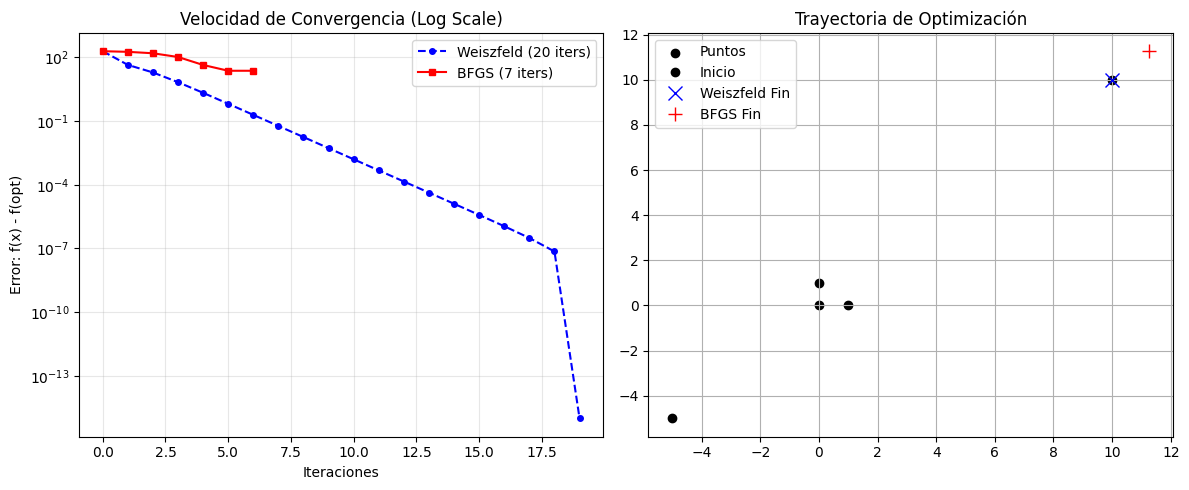

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

# ==============================================================================
# 1. IMPLEMENTACIÓN DE WEISZFELD
# ==============================================================================
class FermatWeberWeiszfeld:
    def __init__(self, points, weights=None, epsilon=1e-8, max_iter=1000):
        self.points = np.array(points)
        self.m = len(points)
        self.n = len(points[0])
        self.weights = np.array(weights) if weights is not None else np.ones(self.m)
        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective_function(self, x):
        return sum(self.weights[i] * np.linalg.norm(self.points[i] - x) for i in range(self.m))

    def solve(self, x0):
        x = x0.copy()
        history = {'obj': [], 'times': []}
        start_time = time.time()

        for k in range(self.max_iter):
            current_obj = self.objective_function(x)
            history['obj'].append(current_obj)
            history['times'].append(time.time() - start_time)

            numerator = np.zeros(self.n)
            denominator = 0.0

            for i in range(self.m):
                dist = np.linalg.norm(self.points[i] - x)
                dist = max(dist, 1e-12)

                weight_factor = self.weights[i] / dist
                numerator += weight_factor * self.points[i]
                denominator += weight_factor

            if denominator == 0: break
            x_new = numerator / denominator

            if np.linalg.norm(x_new - x) < self.epsilon:
                break

            x = x_new

        return x, history

# ==============================================================================
# 2. TU IMPLEMENTACIÓN (Región de Confianza + BFGS) CON FIX
# ==============================================================================
class FermatWeberTrustRegionBFGS:
    def __init__(self, points, weights=None, epsilon=1e-8, max_iter=1000):
        self.points = np.array(points)
        self.m = len(points)
        self.n = len(points[0])
        self.weights = np.array(weights) if weights is not None else np.ones(self.m)
        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective_function(self, x):
        return sum(self.weights[i] * np.linalg.norm(self.points[i] - x) for i in range(self.m))

    def gradient(self, x):
        grad = np.zeros(self.n)
        for i in range(self.m):
            diff = x - self.points[i]
            dist = np.linalg.norm(diff)
            if dist > 1e-12:
                grad += self.weights[i] * diff / dist
        return grad

    def dogleg_step(self, grad, B, delta):
        bg = B @ grad
        curvature = grad.T @ bg
        if curvature <= 1e-10:
            norm_g = np.linalg.norm(grad)
            return -(delta / norm_g) * grad if norm_g > 0 else np.zeros_like(grad)

        pU = - ((grad.T @ grad) / curvature) * grad
        if np.linalg.norm(pU) >= delta: return (delta / np.linalg.norm(pU)) * pU

        try: pB = -np.linalg.solve(B, grad)
        except: pB = pU

        if np.linalg.norm(pB) <= delta: return pB

        pU_pB = pB - pU
        a = pU_pB.T @ pU_pB
        b = 2 * pU.T @ pU_pB
        c = pU.T @ pU - delta**2

        if abs(a) < 1e-10: return pU

        tau = (-b + np.sqrt(max(0, b**2 - 4*a*c))) / (2*a)
        return pU + tau * pU_pB

    def solve(self, x0):
        x = x0.copy()
        delta = 1.0
        B = np.eye(self.n)
        history = {'obj': [], 'times': []}
        start_time = time.time()

        grad = self.gradient(x)

        for k in range(self.max_iter):
            current_obj = self.objective_function(x)
            history['obj'].append(current_obj)
            history['times'].append(time.time() - start_time)

            grad_norm = np.linalg.norm(grad)

            # Criterio 1: Gradiente
            if grad_norm < self.epsilon:
                break

            # Criterio 2: Estancamiento (EL FIX)
            if k > 0 and abs(history['obj'][-1] - history['obj'][-2]) < 1e-12:
                break

            p = self.dogleg_step(grad, B, delta)
            pred_red = -(grad.T @ p + 0.5 * p.T @ B @ p)
            x_candidate = x + p
            actual_red = current_obj - self.objective_function(x_candidate)
            rho = actual_red / pred_red if pred_red > 0 else -1

            if rho > 0.1:
                x_new = x_candidate
                grad_new = self.gradient(x_new)
                s = x_new - x
                y = grad_new - grad

                if k == 0 and y.T @ s > 1e-10:
                    B = ((y.T @ y) / (y.T @ s)) * np.eye(self.n)

                if s.T @ y > 1e-10:
                    Bs = B @ s
                    term1 = np.outer(Bs, Bs) / (s.T @ Bs)
                    term2 = np.outer(y, y) / (s.T @ y)
                    B = B - term1 + term2

                x = x_new
                grad = grad_new
                if rho > 0.75 and np.linalg.norm(p) > 0.8 * delta: delta = min(delta * 2, 100.0)
            else:
                delta *= 0.5

        return x, history

# Ejecución
weights = [1, 1, 1, 10]
points = [np.array([0, 0]), np.array([1, 0]), np.array([0, 1]), np.array([10, 10])]
start_point = np.array([-5.0, -5.0])

solver_w = FermatWeberWeiszfeld(points, weights)
x_w, hist_w = solver_w.solve(start_point)

solver_b = FermatWeberTrustRegionBFGS(points, weights)
x_b, hist_b = solver_b.solve(start_point)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Convergencia
min_val = min(min(hist_w['obj']), min(hist_b['obj']))
ax1.semilogy([x - min_val + 1e-15 for x in hist_w['obj']], 'b--o', label=f'Weiszfeld ({len(hist_w["obj"])} iters)', markersize=4)
ax1.semilogy([x - min_val + 1e-15 for x in hist_b['obj']], 'r-s', label=f'BFGS ({len(hist_b["obj"])} iters)', markersize=4)
ax1.set_title('Velocidad de Convergencia (Log Scale)')
ax1.set_xlabel('Iteraciones')
ax1.set_ylabel('Error: f(x) - f(opt)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Trayectoria
pts = np.array(points)
ax2.scatter(pts[:,0], pts[:,1], c='black', label='Puntos')
ax2.plot(start_point[0], start_point[1], 'ko', label='Inicio')
ax2.plot(x_w[0], x_w[1], 'bx', markersize=10, label='Weiszfeld Fin')
ax2.plot(x_b[0], x_b[1], 'r+', markersize=10, label='BFGS Fin')
ax2.set_title('Trayectoria de Optimización')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('convergence_comparison.png')

--- Iniciando Comparación en R^5 con 1000 sitios ---
Weiszfeld convergió en iter 10
BFGS convergió en iter 12


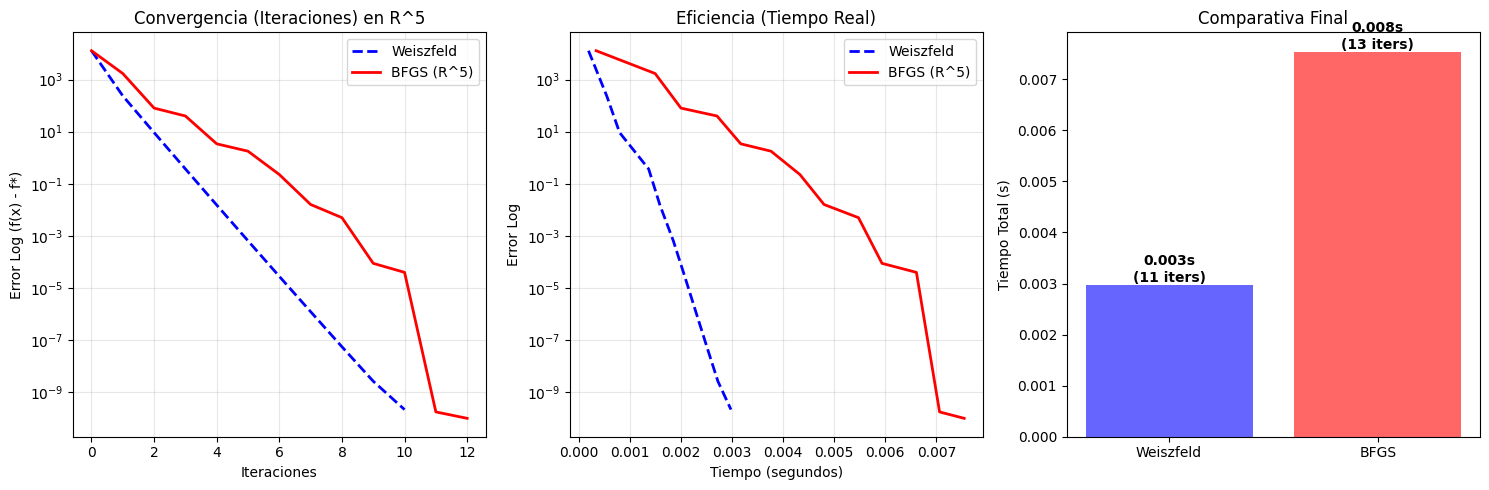


Distancia entre soluciones finales: 5.97e-06
Solución BFGS (R^5): [49.37 49.08 49.15 50.41 50.21]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==============================================================================
# 1. ALGORITMOS (Optimizados para cualquier dimensión R^n)
# ==============================================================================

class FermatWeberWeiszfeld:
    def __init__(self, points, weights=None, epsilon=1e-6, max_iter=1000):
        self.points = np.array(points)
        self.m, self.n = self.points.shape
        self.weights = np.array(weights) if weights is not None else np.ones(self.m)
        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective(self, x):
        # Cálculo vectorizado para velocidad
        diff = self.points - x
        dists = np.linalg.norm(diff, axis=1)
        return np.dot(self.weights, dists)

    def solve(self, x0):
        x = x0.copy()
        hist = {'obj': [], 'times': []}
        start = time.time()

        for k in range(self.max_iter):
            hist['obj'].append(self.objective(x))
            hist['times'].append(time.time() - start)

            # Vectorización del paso de Weiszfeld
            diff = self.points - x
            dists = np.linalg.norm(diff, axis=1)
            # Evitar división por cero
            dists = np.maximum(dists, 1e-12)

            inv_dists = self.weights / dists
            sum_inv_dists = np.sum(inv_dists)

            if sum_inv_dists == 0: break

            # x_new = sum(w_i * a_i / d_i) / sum(w_i / d_i)
            # Usamos matricial: (inv_dists @ points) es la suma ponderada de vectores
            x_new = (inv_dists @ self.points) / sum_inv_dists

            if np.linalg.norm(x_new - x) < self.epsilon:
                print(f"Weiszfeld convergió en iter {k}")
                break
            x = x_new

        return x, hist

class FermatWeberBFGS:
    def __init__(self, points, weights=None, epsilon=1e-6, max_iter=1000):
        self.points = np.array(points)
        self.m, self.n = self.points.shape
        self.weights = np.array(weights) if weights is not None else np.ones(self.m)
        self.epsilon = epsilon
        self.max_iter = max_iter

    def objective(self, x):
        diff = self.points - x
        dists = np.linalg.norm(diff, axis=1)
        return np.dot(self.weights, dists)

    def gradient(self, x):
        diff = x - self.points # Note el orden x - a_i para el gradiente
        dists = np.linalg.norm(diff, axis=1)
        dists = np.maximum(dists, 1e-12)

        # grad = sum( w_i * (x - a_i) / ||x - a_i|| )
        # factor tiene forma (m,)
        factors = self.weights / dists
        # Multiplicación broadcast: (m,1) * (m,n) -> suma col -> (n,)
        grad = np.sum(factors[:, np.newaxis] * diff, axis=0)
        return grad

    def solve(self, x0):
        x = x0.copy()
        n = len(x)
        B = np.eye(n) # Matriz identidad 5x5
        hist = {'obj': [], 'times': []}
        start = time.time()

        grad = self.gradient(x)

        # Parámetros de Line Search simple (Wolfe conditions son ideales,
        # pero usaremos backtracking simple para este demo)
        alpha_init = 1.0
        rho = 0.5
        c = 1e-4

        for k in range(self.max_iter):
            hist['obj'].append(self.objective(x))
            hist['times'].append(time.time() - start)

            if np.linalg.norm(grad) < self.epsilon:
                print(f"BFGS convergió en iter {k}")
                break

            # Dirección de descenso: p = -B_inv * grad
            # Aquí B es la aproximación de la Hessiana inversa directamente
            # O si B es Hessiana, p = solve(B, -grad).
            # Para simplicidad pura y robustez numérica rápida:
            try:
                p = -np.linalg.solve(B, grad)
            except:
                p = -grad # Fallback a gradiente

            # Backtracking Line Search
            alpha = alpha_init
            f_curr = hist['obj'][-1]
            while self.objective(x + alpha * p) > f_curr + c * alpha * np.dot(grad, p):
                alpha *= rho
                if alpha < 1e-8: break

            x_new = x + alpha * p
            grad_new = self.gradient(x_new)
            s = x_new - x
            y = grad_new - grad

            # BFGS Update (con chequeo de curvatura)
            if np.dot(s, y) > 1e-10:
                rho_bfgs = 1.0 / np.dot(s, y)
                I = np.eye(n)
                # Fórmula BFGS Inversa (H_new = ...)
                # O Fórmula BFGS Directa (B_new = ...). Aquí usamos Directa B.
                # Actualización de B (Hessiana aproximada):
                Bs = B @ s
                B = B - np.outer(Bs, Bs)/np.dot(s, Bs) + np.outer(y, y)/np.dot(y, s)

            x = x_new
            grad = grad_new

        return x, hist

# ==============================================================================
# 2. CONFIGURACIÓN DEL EXPERIMENTO EN R^5
# ==============================================================================
np.random.seed(123)
N_POINTS = 1000  # Cantidad de puntos (clientes/sitios)
DIMENSION = 5    # R^5

# Generamos puntos aleatorios en un hipercubo de 100x100x100x100x100
points = np.random.rand(N_POINTS, DIMENSION) * 100
weights = np.random.rand(N_POINTS)

# Punto de inicio aleatorio en el espacio R^5
start_point = np.random.uniform(0, 100, DIMENSION)

print(f"--- Iniciando Comparación en R^{DIMENSION} con {N_POINTS} sitios ---")

solver_w = FermatWeberWeiszfeld(points, weights, epsilon=1e-5)
x_w, hist_w = solver_w.solve(start_point)

solver_b = FermatWeberBFGS(points, weights, epsilon=1e-5)
x_b, hist_b = solver_b.solve(start_point)

# ==============================================================================
# 3. VISUALIZACIÓN
# ==============================================================================
min_val = min(min(hist_w['obj']), min(hist_b['obj']))
# Ajuste para escala logarítmica
err_w = np.array(hist_w['obj']) - min_val + 1e-10
err_b = np.array(hist_b['obj']) - min_val + 1e-10

plt.figure(figsize=(15, 5))

# --- Gráfica 1: Convergencia por ITERACIONES ---
plt.subplot(1, 3, 1)
plt.semilogy(err_w, 'b--', label='Weiszfeld', linewidth=2)
plt.semilogy(err_b, 'r-', label='BFGS (R^5)', linewidth=2)
plt.title(f'Convergencia (Iteraciones) en R^{DIMENSION}')
plt.xlabel('Iteraciones')
plt.ylabel('Error Log (f(x) - f*)')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfica 2: Convergencia por TIEMPO ---
plt.subplot(1, 3, 2)
plt.semilogy(hist_w['times'], err_w, 'b--', label='Weiszfeld', linewidth=2)
plt.semilogy(hist_b['times'], err_b, 'r-', label='BFGS (R^5)', linewidth=2)
plt.title('Eficiencia (Tiempo Real)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Error Log')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Gráfica 3: Resumen Final ---
plt.subplot(1, 3, 3)
methods = ['Weiszfeld', 'BFGS']
final_times = [hist_w['times'][-1], hist_b['times'][-1]]
iter_counts = [len(hist_w['times']), len(hist_b['times'])]

bars = plt.bar(methods, final_times, color=['blue', 'red'], alpha=0.6)
plt.ylabel('Tiempo Total (s)')
plt.title('Comparativa Final')

# Añadir etiquetas de texto sobre las barras
for bar, iters in zip(bars, iter_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}s\n({iters} iters)',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Validación numérica de la solución
dist_sol = np.linalg.norm(x_w - x_b)
print(f"\nDistancia entre soluciones finales: {dist_sol:.2e}")
print(f"Solución BFGS (R^5): {np.round(x_b, 2)}")

--- COMPARACIÓN CON DATOS MAL CONDICIONADOS (R^5) ---
Weiszfeld convergió en iter 44
BFGS convergió en iter 13


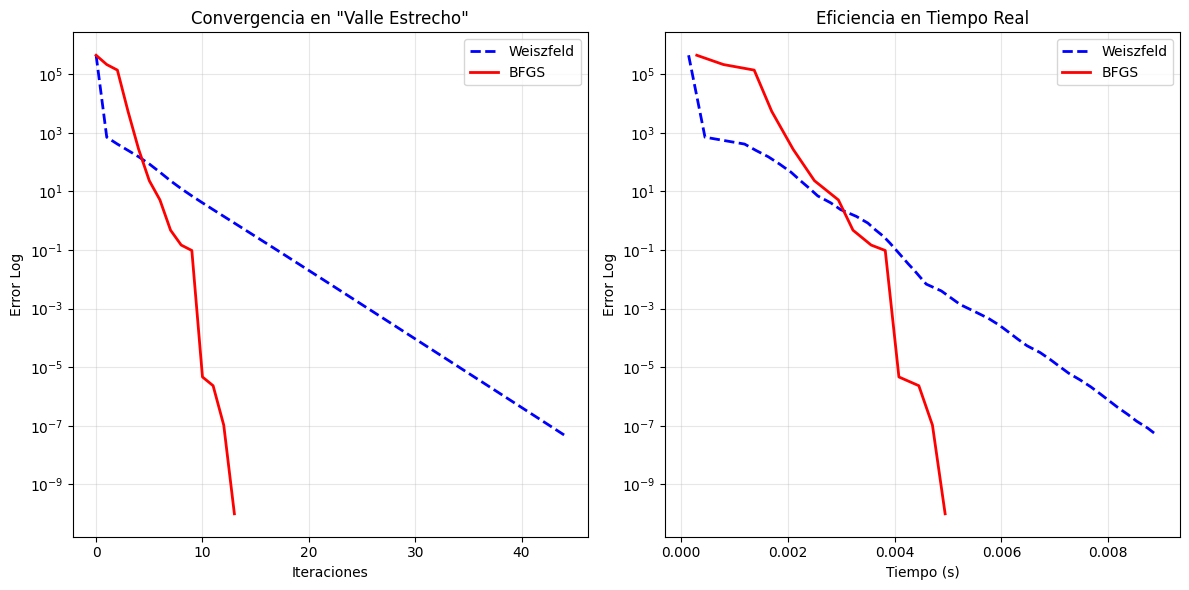


Resultados Finales:
Weiszfeld: 45 iters | Tiempo: 0.0089s
BFGS     : 14 iters | Tiempo: 0.0049s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- REUTILIZAMOS LAS CLASES ANTERIORES (Copia y pega las clases si no están en memoria) ---
# (Asegúrate de tener definidas FermatWeberWeiszfeld y FermatWeberBFGS del mensaje anterior)

# ==============================================================================
# ESCENARIO DE "MAL CONDICIONAMIENTO" (ILL-CONDITIONED)
# ==============================================================================
np.random.seed(42)
N_POINTS = 1000
DIMENSION = 5

# Generamos puntos básicos
points = np.random.rand(N_POINTS, DIMENSION)

# --- EL TRUCO ---
# Escalamos las dimensiones drásticamente para crear un "Valle Estrecho"
# Eje 0: x1000, Eje 1: x100, Eje 2: x10 ...
scales = np.array([1000.0, 100.0, 10.0, 1.0, 0.1])
points = points * scales  # Esto deforma el espacio

weights = np.random.rand(N_POINTS)
start_point = np.mean(points, axis=0) + 500 # Empezamos lejos

print(f"--- COMPARACIÓN CON DATOS MAL CONDICIONADOS (R^5) ---")

# 1. Weiszfeld
solver_w = FermatWeberWeiszfeld(points, weights, epsilon=1e-4, max_iter=2000)
x_w, hist_w = solver_w.solve(start_point)

# 2. BFGS
solver_b = FermatWeberBFGS(points, weights, epsilon=1e-4, max_iter=2000)
x_b, hist_b = solver_b.solve(start_point)

# ==============================================================================
# VISUALIZACIÓN
# ==============================================================================
min_val = min(min(hist_w['obj']), min(hist_b['obj']))
err_w = np.array(hist_w['obj']) - min_val + 1e-10
err_b = np.array(hist_b['obj']) - min_val + 1e-10

plt.figure(figsize=(12, 6))

# Gráfica de Convergencia (Iteraciones)
plt.subplot(1, 2, 1)
plt.semilogy(err_w, 'b--', label='Weiszfeld', linewidth=2)
plt.semilogy(err_b, 'r-', label='BFGS', linewidth=2)
plt.title('Convergencia en "Valle Estrecho"')
plt.xlabel('Iteraciones')
plt.ylabel('Error Log')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica de Tiempo
plt.subplot(1, 2, 2)
plt.semilogy(hist_w['times'], err_w, 'b--', label='Weiszfeld', linewidth=2)
plt.semilogy(hist_b['times'], err_b, 'r-', label='BFGS', linewidth=2)
plt.title('Eficiencia en Tiempo Real')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error Log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResultados Finales:")
print(f"Weiszfeld: {len(hist_w['obj'])} iters | Tiempo: {hist_w['times'][-1]:.4f}s")
print(f"BFGS     : {len(hist_b['obj'])} iters | Tiempo: {hist_b['times'][-1]:.4f}s")

Run  | Start (Dim 0,1)      | Weiszfeld Iters | BFGS Iters     
-----------------------------------------------------------------
1    | [90.3, 21.1]...       | 10              | 13             
2    | [26.2, 21.1]...       | 11              | 13             
3    | [86.2, 5.2]...       | 11              | 13             


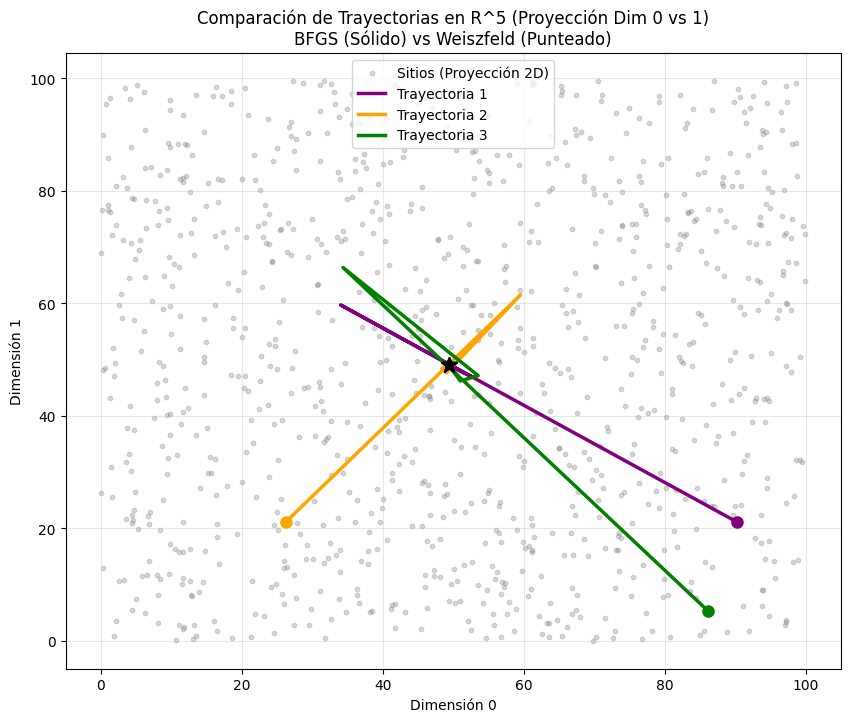

In [ ]:
# ==============================================================================
# BLOQUE DE VISUALIZACIÓN DE TRAYECTORIAS (3 PUNTOS ALEATORIOS)
# ==============================================================================

# 1. REDEFINICIÓN TEMPORAL: Hacemos que los métodos guarden la trayectoria (path)
#    Esto modifica tus clases existentes sin necesidad de volver a escribirlas.
def solve_w_with_path(self, x0):
    x = x0.copy()
    path = [x.copy()]
    for k in range(self.max_iter):
        # Lógica Weiszfeld
        diff = self.points - x
        dists = np.maximum(np.linalg.norm(diff, axis=1), 1e-12)
        inv_dists = self.weights / dists
        sum_inv = np.sum(inv_dists)
        if sum_inv == 0: break
        x_new = (inv_dists @ self.points) / sum_inv

        path.append(x_new.copy()) # <--- Guardamos paso
        if np.linalg.norm(x_new - x) < self.epsilon: break
        x = x_new
    return np.array(path)

def solve_b_with_path(self, x0):
    x = x0.copy()
    n = len(x)
    B = np.eye(n)
    path = [x.copy()]
    grad = self.gradient(x)

    for k in range(self.max_iter):
        if np.linalg.norm(grad) < self.epsilon: break

        try: p = -np.linalg.solve(B, grad)
        except: p = -grad

        # Line Search simple (Backtracking)
        alpha = 1.0
        while self.objective(x + alpha * p) > self.objective(x) + 1e-4 * alpha * np.dot(grad, p):
            alpha *= 0.5
            if alpha < 1e-8: break

        x_new = x + alpha * p
        path.append(x_new.copy()) # <--- Guardamos paso

        # BFGS Update
        grad_new = self.gradient(x_new)
        s = x_new - x
        y = grad_new - grad
        if np.dot(s, y) > 1e-10:
            Bs = B @ s
            B = B - np.outer(Bs, Bs)/np.dot(s, Bs) + np.outer(y, y)/np.dot(y, s)

        x = x_new
        grad = grad_new
    return np.array(path)

# Aplicamos el parche a las clases que ya tienes en memoria
FermatWeberWeiszfeld.solve_path = solve_w_with_path
FermatWeberBFGS.solve_path = solve_b_with_path

# ------------------------------------------------------------------------------
# 2. EXPERIMENTO: 3 Puntos de Inicio Aleatorios
# ------------------------------------------------------------------------------
# Generamos 3 puntos de inicio aleatorios dentro del rango de los datos
bounds_min = np.min(points, axis=0)
bounds_max = np.max(points, axis=0)
start_points = [np.random.uniform(bounds_min, bounds_max) for _ in range(3)]

# Instanciamos los solvers (reusando tus variables points y weights)
solver_w = FermatWeberWeiszfeld(points, weights, epsilon=1e-4)
solver_b = FermatWeberBFGS(points, weights, epsilon=1e-4)

plt.figure(figsize=(10, 8))

# Graficamos los sitios (Solo dim 0 y 1 para visualizar en 2D)
plt.scatter(points[:,0], points[:,1], c='gray', alpha=0.3, s=10, label='Sitios (Proyección 2D)')

colors = ['purple', 'orange', 'green']

print(f"{'Run':<4} | {'Start (Dim 0,1)':<20} | {'Weiszfeld Iters':<15} | {'BFGS Iters':<15}")
print("-" * 65)

for i, start_p in enumerate(start_points):
    # Ejecutar ambos métodos
    path_w = solver_w.solve_path(start_p)
    path_b = solver_b.solve_path(start_p)

    # Imprimir métricas
    print(f"{i+1:<4} | [{start_p[0]:.1f}, {start_p[1]:.1f}]...       | {len(path_w):<15} | {len(path_b):<15}")

    # Graficar Trayectorias
    # Weiszfeld = Línea punteada
    plt.plot(path_w[:,0], path_w[:,1], linestyle='--', color=colors[i], linewidth=1.5, alpha=0.7)
    # BFGS = Línea sólida
    plt.plot(path_b[:,0], path_b[:,1], linestyle='-', color=colors[i], linewidth=2.5, label=f'Trayectoria {i+1}')

    # Marcar Inicio y Fin
    plt.plot(start_p[0], start_p[1], 'o', color=colors[i], markersize=8) # Inicio
    plt.plot(path_b[-1,0], path_b[-1,1], '*', color='black', markersize=12, zorder=10) # Fin (Optimo)

plt.title(f'Comparación de Trayectorias en R^{points.shape[1]} (Proyección Dim 0 vs 1)\nBFGS (Sólido) vs Weiszfeld (Punteado)')
plt.xlabel('Dimensión 0')
plt.ylabel('Dimensión 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()